# Your Transformer is Secretly Linear

### Deep Learning (83882) - Final Project

**Group members:** Dvir Musari (216687566), Idan Rosen (330841131), Roi Khouri (330909037)

**Paper:** A. Razzhigaev, M. Mikhalchuk, E. Goncharova, N. Gerasimenko, I. Oseledets, D. Dimitrov,
A. Kuznetsov, *"Your Transformer is Secretly Linear"*, Findings of ACL 2024, arXiv:2405.12250

**Original code:** https://github.com/AIRI-Institute/LLM-Microscope

---

## How this notebook is organized

The notebook follows the structure recommended in the project instructions. Every section starts
with a short markdown cell that says what the section does and why it is there.

| Section | Content |
|---|---|
| **Setup** | Environment check and the shared helpers. Run this first. |
| **1** | Motivation and problem background |
| **2** | The solution proposed in the paper |
| **3** | Review of the results reported in the paper |
| **4** | The experiments we ran and the results we got |
| **5** | Limitations of the paper's solution, and the modifications we examined |
| **6** | Challenges we encountered |
| **7** | Summary of everything |

Run the cells in order. Section 4.3 is the only part that trains a model; everything else is
inference only.

# Setup

## What this section does

Three things, in order:

1. **Checks the environment.** Confirms that PyTorch can actually reach the GPU, and stops with a
   clear message if it cannot. This is the single most common thing that goes wrong - see `SETUP.md`.
2. **Loads the text data.** WikiText-2, which we use both as the text we push through the models and
   as the test set for perplexity.
3. **Defines the shared helpers** that every later section calls: loading a model, cutting text into
   batches, and freeing GPU memory.

Nothing here is an experiment. It is the scaffolding the rest of the notebook stands on.

## Setup 1 - environment check (MUST RUN FIRST)

If the cell below does not say **ALL GOOD**, stop and fix it before continuing. The install
commands are in `SETUP.md`; the short version is:

```bash
pip uninstall -y torch torchvision torchaudio
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126
pip install transformers datasets accelerate matplotlib pandas tqdm
```

On Windows a plain `pip install torch` gives a CPU-only build: it installs and imports without any
error, and then `torch.cuda.is_available()` is `False` forever. The `--index-url` is what avoids that.

In [2]:
# Environment report: the hardware and library versions these results were produced on.
import sys
import torch

print("python :", sys.version.split()[0])
print("torch  :", torch.__version__, "| CUDA", torch.version.cuda)

if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print("device :", props.name)
    print("VRAM   : %.1f GB" % (props.total_memory / 1024 ** 3))
else:
    print("device : CPU")

python : 3.13.14
torch  : 2.14.0+cu126 | CUDA 12.6
device : NVIDIA GeForce RTX 3050 Ti Laptop GPU
VRAM   : 4.0 GB


In [3]:
# The analysis also runs on CPU, but it takes hours and the fine-tuning in section 4.3
# is not practical there. Set ALLOW_CPU = True to run a reduced version without a GPU.
ALLOW_CPU = False

if not torch.cuda.is_available() and not ALLOW_CPU:
    raise SystemError(
        "No GPU available. Set ALLOW_CPU = True to run a reduced version on the CPU."
    )

## Setup 2 - imports, seeds and settings

In [5]:
import os

# Set before huggingface_hub is imported, to suppress its Windows symlink warning.
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")

import gc
import math
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from tqdm.auto import tqdm

# fixing the seeds so the results are reproducible
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(name):
    plt.savefig(os.path.join(FIG_DIR, name + ".png"), dpi=150, bbox_inches="tight")


def free_memory():
    """
    Releases GPU memory that is no longer referenced. Callers must `del` the model in their
    own scope first; deleting a reference inside a helper does not release the caller's.
    """
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Using device: cuda


In [6]:
# Models analysed. The paper uses OPT-1.3B, Llama2-7B and GPT2-XL, which do not fit in 4 GB
# of VRAM. Four small models from four different families are used instead: the paper's claim
# concerns the architecture rather than any single checkpoint.
DECODER_MODELS = [
    "gpt2",                      # 124M, 12 layers, d=768
    "gpt2-medium",               # 355M, 24 layers, d=1024
    "facebook/opt-125m",         # 125M, 12 layers, d=768
    "EleutherAI/pythia-160m",    # 162M, 12 layers, d=768
]

ENCODER_MODELS = ["bert-base-uncased", "roberta-base"]   # for section 5.1

# n = SEQ_LEN * N_SEQS is the number of token embeddings the linearity score is fitted on.
# Section 5.2 measures how the score depends on n and runs a control at a larger value.
if device.type == "cuda":
    SEQ_LEN = 256
    N_SEQS = 32          # -> n = 8192 tokens
    MAX_TOKENS = 40000   # cap, so a big n does not blow up host RAM
else:
    SEQ_LEN = 128
    N_SEQS = 8
    MAX_TOKENS = 4000
    DECODER_MODELS = ["gpt2"]
    ENCODER_MODELS = ["bert-base-uncased"]

print(f"SEQ_LEN={SEQ_LEN}  N_SEQS={N_SEQS}  ->  n = {SEQ_LEN*N_SEQS} tokens per score")

SEQ_LEN=256  N_SEQS=32  ->  n = 8192 tokens per score


## Setup 3 - loading models and text

**A note on dataset names.** Recent versions of the `datasets` library dropped the old
un-namespaced dataset names, so `load_dataset("wikitext", ...)` now raises
`HfUriError: ... Repository id must be 'namespace/name'`. WikiText lives under
`Salesforce/wikitext`. We try a list of candidate names so the notebook works on old and new
versions of the library alike.

In [7]:
import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModel

# transformers v5 renamed the from_pretrained argument torch_dtype -> dtype
TF_MAJOR = int(transformers.__version__.split(".")[0])
DTYPE_KW = "dtype" if TF_MAJOR >= 5 else "torch_dtype"

DEFAULT_DTYPE = torch.float16 if torch.cuda.is_available() else torch.float32


def load_model(name, causal=True, dtype=None):
    """
    Loads a model and its tokenizer, moves it to the device and puts it in eval mode.
    causal=True  -> a decoder  (AutoModelForCausalLM)
    causal=False -> an encoder (AutoModel)
    """
    dtype = dtype or DEFAULT_DTYPE
    tokenizer = AutoTokenizer.from_pretrained(name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    cls = AutoModelForCausalLM if causal else AutoModel
    model = cls.from_pretrained(name, **{DTYPE_KW: dtype})
    model.to(device)
    model.eval()
    model.config.use_cache = False   # inference only; also keeps the block outputs simple
    return model, tokenizer

In [8]:
from datasets import load_dataset


def try_load(candidates, split_check="train"):
    """Tries several dataset ids in order and returns the first one that loads."""
    errors = []
    for name, config in candidates:
        try:
            ds = load_dataset(name, config) if config else load_dataset(name)
            if split_check in ds:
                print(f"loaded: {name}" + (f" [{config}]" if config else ""))
                return ds
            errors.append((name, f"no '{split_check}' split"))
        except Exception as e:
            errors.append((name, f"{type(e).__name__}: {str(e)[:110]}"))

    print("none of the candidates could be loaded:")
    for name, err in errors:
        print(f"   {name}: {err}")
    raise RuntimeError("could not load the dataset - see the errors above")


def load_wikitext():
    ds = try_load([
        ("Salesforce/wikitext", "wikitext-2-raw-v1"),   # current name
        ("wikitext", "wikitext-2-raw-v1"),              # old name, older library versions
        ("mindchain/wikitext2", None),                  # mirror
    ])
    train_text = "\n\n".join([t for t in ds["train"]["text"] if len(t.strip()) > 0])
    test_text = "\n\n".join([t for t in ds["test"]["text"] if len(t.strip()) > 0])
    return train_text, test_text


train_text, test_text = load_wikitext()
print("train characters:", len(train_text))
print("test characters :", len(test_text))

loaded: Salesforce/wikitext [wikitext-2-raw-v1]
train characters: 10940522
test characters : 1291402


In [9]:
def make_batches(tokenizer, text, seq_len=SEQ_LEN, n_seqs=N_SEQS):
    """
    Tokenizes text and cuts it into n_seqs sequences of length seq_len.
    Returns a tensor of shape (n_seqs, seq_len).
    """
    needed = seq_len * n_seqs

    # English averages ~4 characters per token; 8x gives a safe margin.
    chunk = text[: needed * 8]

    # verbose=False suppresses the max-sequence-length warning: the ids are cut into
    # seq_len windows below and no long sequence is ever fed to the model.
    ids = tokenizer(chunk, return_tensors="pt", verbose=False).input_ids[0]

    if ids.numel() < needed:
        raise ValueError(f"not enough tokens: got {ids.numel()}, need {needed}")

    return ids[:needed].view(n_seqs, seq_len)

---

# Section 1 - Motivation and Problem Background

## What this section does

No code. It states the problem the paper attacks and why it is worth attacking, so that every
number later in the notebook has something to mean.

## The problem

Transformers are the standard architecture for language models, and we still do not have a good
answer to a very basic question: **what does one layer actually do?**

A modern decoder stacks 12 to 80 identical blocks, each containing multi-head self-attention and a
non-linear MLP. The usual assumption is that every one of those blocks performs a rich non-linear
computation that the model could not manage without. Nobody had measured how non-linear a single
block really is.

## Why the residual connection makes this a real question

A decoder block does not replace its input. It **adds** to it:

```
h(i+1) = h(i) + Attention( LayerNorm( h(i) ) )
h(i+2) = h(i+1) + MLP( LayerNorm( h(i+1) ) )
```

So there is one vector per token that travels the whole depth of the network, from the embedding
layer to the output head - usually called the **residual stream**. Blocks are not a pipeline; they
sit alongside a shared bus. Each one reads the stream, computes something, and writes the result
back by addition.

If the thing each block writes back is *small* compared with what the stream already carries, then
`h(i+1)` is very close to `h(i)`, and the mapping between them is close to the identity - which is
linear. That is the observation the paper starts from.

## Why anyone should care

Two reasons.

**Interpretability.** If a layer is close to a linear map, then it adds nothing that a plain
`nn.Linear` could not add. That reframes what "depth" is buying us: not a sequence of rich
transformations, but the accumulation of many small updates on one shared representation.

**Compression.** If a layer is close to a linear map, we should be able to delete it, or replace it
with an actual matrix, and lose very little. That is a cheap way to make a model smaller and faster,
and it is the practical half of the paper.

## What "linear" means here

This is the part that is easy to get wrong. Saying "layer *i* is linear" does **not** mean the layer
contains no non-linear operations. It means something stronger and testable:

> there exists a single matrix `A`, the same one for every token, such that `h(i+1) ~ h(i) @ A`.

One matrix. Not one per token, not one per sentence. If such an `A` exists, the block adds no
expressive power beyond a linear layer.

---

# Section 2 - The Solution Proposed in the Paper

## What this section does

Implements the paper's central tool - the **linearity score** - and checks it on cases where we
already know the right answer, before we trust it on real models.

## The metric

Let `X` and `Y` be the token embeddings of two consecutive layers, each of shape `n x d`
(n tokens, d dimensions). Center both and normalize each by its Frobenius norm:

$$\tilde{X} = \frac{X - \bar{X}}{\|X - \bar{X}\|_F}, \qquad \tilde{Y} = \frac{Y - \bar{Y}}{\|Y - \bar{Y}\|_F}$$

then

$$\text{linearity score} = 1 - \min_{A \in \mathbb{R}^{d \times d}} \|\tilde{X}A - \tilde{Y}\|_F^2$$

The paper describes this as a generalization of Procrustes similarity: Procrustes searches only over
rotations, this searches over **all** linear maps `A`.

## What the metric really is

There is a simpler way to see it. Because `Y` was normalized to unit Frobenius norm,
$\|\tilde{Y}\|^2 = 1$, which is exactly the total sum of squares; and
$\|\tilde{X}A - \tilde{Y}\|^2$ is the residual sum of squares. So

$$\text{score} = 1 - \frac{SS_{res}}{SS_{tot}} = R^2$$

**The linearity score is the $R^2$ of a multivariate linear regression of layer $i+1$ on layer $i$.**
It is the fraction of the next layer's variance that a fixed linear function of the previous layer
explains. Everything you know about $R^2$ carries over - including, as we will see in section 5.2,
that it is biased upward when the number of fitted parameters is large relative to the sample.

## Why it is cheap

The inner minimization is ordinary least squares, so the optimum is closed-form and there is nothing
to train:

$$A^* = (\tilde{X}^\top \tilde{X})^{-1}\tilde{X}^\top \tilde{Y}$$

We add a small ridge term on the diagonal for conditioning, and we do the whole computation in
`float64` on the CPU - the models run in `float16`, which is far too coarse for a quantity that
lives around 0.97 and whose interesting differences are in the third decimal.

In [10]:
@torch.no_grad()
def linearity_score(X, Y, ridge=1e-10):
    """
    Computes  1 - min_A ||X_norm @ A - Y_norm||_F^2  for two sets of embeddings.

    X, Y : tensors of shape (n_tokens, d)
    Returns a float in [0, 1]; 1 means a perfect linear relation.
    """
    # float64 on the cpu: fp16 cannot resolve differences at the third decimal
    X = X.detach().to(torch.float64).cpu()
    Y = Y.detach().to(torch.float64).cpu()

    # centering
    X = X - X.mean(dim=0, keepdim=True)
    Y = Y - Y.mean(dim=0, keepdim=True)

    # normalizing by the frobenius norm makes the score scale invariant
    X = X / (torch.linalg.norm(X) + 1e-12)
    Y = Y / (torch.linalg.norm(Y) + 1e-12)

    # closed form least squares: A = (X^T X + eps*I)^-1 X^T Y
    d = X.shape[1]
    A = torch.linalg.solve(X.T @ X + ridge * torch.eye(d, dtype=torch.float64), X.T @ Y)

    residual = torch.linalg.norm(X @ A - Y) ** 2
    return float(1.0 - residual.item())

### Sanity checks

Before trusting the metric on real models, we check it where the answer is known.

In [18]:
n, d = 4000, 64
X = torch.randn(n, d)
A_true = torch.randn(d, d)

print("exact linear map            :", round(linearity_score(X, X @ A_true), 4), " expect ~1.00")
print("independent random matrix   :", round(linearity_score(X, torch.randn(n, d)), 4), " expect ~d/n =", round(d/n, 4))
print("relu on top of a linear map :", round(linearity_score(X, torch.relu(X @ A_true)), 4), " expect clearly < 1")

# a simulated residual block: a small non-linear update added to a large stream
h = torch.randn(n, d)
block_out = 0.1 * torch.relu(h @ A_true)
print()
print("simulated residual stream   :", round(linearity_score(h, h + block_out), 4), " expect high")
print("the block's output alone    :", round(linearity_score(h, block_out), 4), " expect much lower")

exact linear map            : 1.0  expect ~1.00
independent random matrix   : 0.0159  expect ~d/n = 0.016
relu on top of a linear map : 0.7375  expect clearly < 1

simulated residual stream   : 0.9526  expect high
the block's output alone    : 0.7377  expect much lower


The last two lines are the paper's whole thesis in miniature: the *stream* looks linear, the *block*
does not. The second sanity check also shows the bias we return to in section 5.2 - two completely
unrelated matrices do not score 0, they score about `d/n`.

---

# Section 3 - Review of the Results Reported in the Paper

## What this section does

No code. A brief summary of what the authors report, so that our own numbers in section 4 have
something to be compared against. Deliberately short - the project instructions ask us to keep this
brief and spend the time on our own experiments.

## The paper's three contributions

**1. Analysis.** Across many pretrained decoders - GPT-2, OPT, LLaMA, BLOOM - the linearity score of
the main stream is about **0.99** at almost every depth (their Figure 1). When the residual component
is subtracted, the score drops sharply. So the linearity is a property of the *stream*, not of the
block. Their Figure 3 gives the mechanism: the norm of each block's output is small compared with the
norm of the residual stream it is added to.

**2. Pruning and distillation.** The layers with the highest linearity score can be removed with a
small increase in perplexity. Replacing a removed layer with a linear map, trained with a layer-wise
distillation loss, recovers much of the remaining gap. On OPT-1.3B they keep most of the ARC-easy
accuracy after pruning.

**3. Regularization.** Adding a cosine-similarity penalty during pretraining pushes consecutive
layers to be *less* linear, and small models pretrained this way score better on SuperGLUE and
TinyStories.

## One more result we test directly

The authors also report (their Table 1) that **pretraining slowly decreases linearity while
fine-tuning increases it** - every entry in that table is positive. We reproduce this in section 4.3.

## What we reproduce, and what we do not

We reproduce **(1)** and **(2)** in full on our own hardware. We do **not** reproduce **(3)**: it
requires pretraining a model from scratch, which does not fit on a 4 GB laptop GPU. We say so openly
rather than hand-waving it.

---

# Section 4 - Our Experiments and Results

## What this section does

This is the core of the project - five experiments we ran ourselves.

| | Experiment | The question it answers |
|---|---|---|
| 4.1 | Linearity profiles of four decoders | Does the effect exist at all, and across model families? |
| 4.2 | Norm and cosine analysis | *Why* is the score high? Tests the mechanism, not just the number. |
| 4.3 | Linearity before and after fine-tuning | Is linearity fixed, or does training move it? |
| 4.4 | Depth pruning of the most linear layers | Is the score actually *useful*, or only descriptive? |
| 4.5 | Replacing a pruned layer with a linear map | Can we do better than simply deleting? |

**4.4 is the experiment that carries the argument.** A metric that describes something is
interesting; a metric that tells you which layers you can delete is useful. If removing the most
linear layers hurts less than removing random ones, the score has predictive content.

## Our setup versus the paper's

| | The paper | Us |
|---|---|---|
| Decoders | GPT-2 XL, OPT 2.7B, Llama2-7B, BLOOM | GPT-2, GPT-2-medium, OPT-125M, Pythia-160M |
| Text | internal corpora, TinyStories, SuperGLUE | WikiText-2 (raw) |
| Distillation | layer-wise MSE training | closed-form least squares (section 4.5) |
| Hardware | multi-GPU cluster | one RTX 3050 Ti laptop, 4 GB |

## 4.1 - Linearity profiles of pretrained decoders

### What this experiment does

For each model we push the WikiText sequences through it once with `output_hidden_states=True`,
which gives the residual stream after every block. Then for each consecutive pair `i, i+1` we
compute two scores:

- **with residual (the main stream):** `linearity_score(H[i], H[i+1])` - what the model actually
  passes forward.
- **without residual:** `linearity_score(H[i], H[i+1] - H[i])` - the block's own contribution, with
  the residual connection subtracted out.

The paper's claim is that the first is close to 0.99 everywhere and the second is much lower.
This reproduces Figure 1 of the paper.

In [11]:
@torch.no_grad()
def collect_hidden_states(model, batches, max_tokens=MAX_TOKENS):
    """
    Runs the model on the batches and returns a list of (n_tokens, d) tensors, one per layer.
    Index 0 is the embedding output, index i is the stream after block i - so block i is the
    map from element i to element i+1.
    """
    all_layers = None

    for i in range(batches.shape[0]):
        input_ids = batches[i:i+1].to(device)
        out = model(input_ids, output_hidden_states=True)
        hs = out.hidden_states                # tuple of (num_layers + 1), each (1, seq_len, d)

        if all_layers is None:
            all_layers = [[] for _ in range(len(hs))]
        for layer_idx, h in enumerate(hs):
            all_layers[layer_idx].append(h[0].float().cpu())

        del out, hs

    stacked = [torch.cat(chunks, dim=0) for chunks in all_layers]

    # subsample tokens if needed - the SAME indices for every layer so the pairs stay aligned
    n_tokens = stacked[0].shape[0]
    if n_tokens > max_tokens:
        idx = torch.randperm(n_tokens)[:max_tokens]
        stacked = [h[idx] for h in stacked]

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return stacked


def linearity_profile(hidden_states):
    """Returns (with_residual, without_residual) score lists, one entry per block."""
    with_residual, without_residual = [], []

    for i in range(len(hidden_states) - 1):
        X, Y = hidden_states[i], hidden_states[i + 1]
        with_residual.append(linearity_score(X, Y))
        without_residual.append(linearity_score(X, Y - X))   # residual stream removed

    return with_residual, without_residual

In [20]:
# One model at a time, to stay within GPU memory.
results = {}

for model_name in DECODER_MODELS:
    print(f"\n=== {model_name} ===")
    model, tokenizer = load_model(model_name, causal=True)
    batches = make_batches(tokenizer, train_text)

    hidden_states = collect_hidden_states(model, batches)
    with_res, without_res = linearity_profile(hidden_states)

    results[model_name] = {
        "with_residual": with_res,
        "without_residual": without_res,
        "n_layers": len(with_res),
        "d_model": hidden_states[0].shape[1],
        "n_tokens": hidden_states[0].shape[0],
    }
    print(f"layers: {len(with_res)},  d = {hidden_states[0].shape[1]},  n = {hidden_states[0].shape[0]}")
    print(f"mean linearity WITH residual   : {np.mean(with_res):.4f}")
    print(f"mean linearity WITHOUT residual: {np.mean(without_res):.4f}")

    del model, hidden_states, batches
    free_memory()


=== gpt2 ===


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

layers: 12,  d = 768,  n = 8192
mean linearity WITH residual   : 0.9720
mean linearity WITHOUT residual: 0.6724
   GPU: 0.01 GB allocated, 0.02 GB reserved

=== gpt2-medium ===


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

layers: 24,  d = 1024,  n = 8192
mean linearity WITH residual   : 0.9854
mean linearity WITHOUT residual: 0.6211
   GPU: 0.01 GB allocated, 0.02 GB reserved

=== facebook/opt-125m ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

layers: 12,  d = 768,  n = 8192
mean linearity WITH residual   : 0.9914
mean linearity WITHOUT residual: 0.7384
   GPU: 0.01 GB allocated, 0.02 GB reserved

=== EleutherAI/pythia-160m ===


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

layers: 12,  d = 768,  n = 8192
mean linearity WITH residual   : 0.9306
mean linearity WITHOUT residual: 0.7821
   GPU: 0.01 GB allocated, 0.02 GB reserved


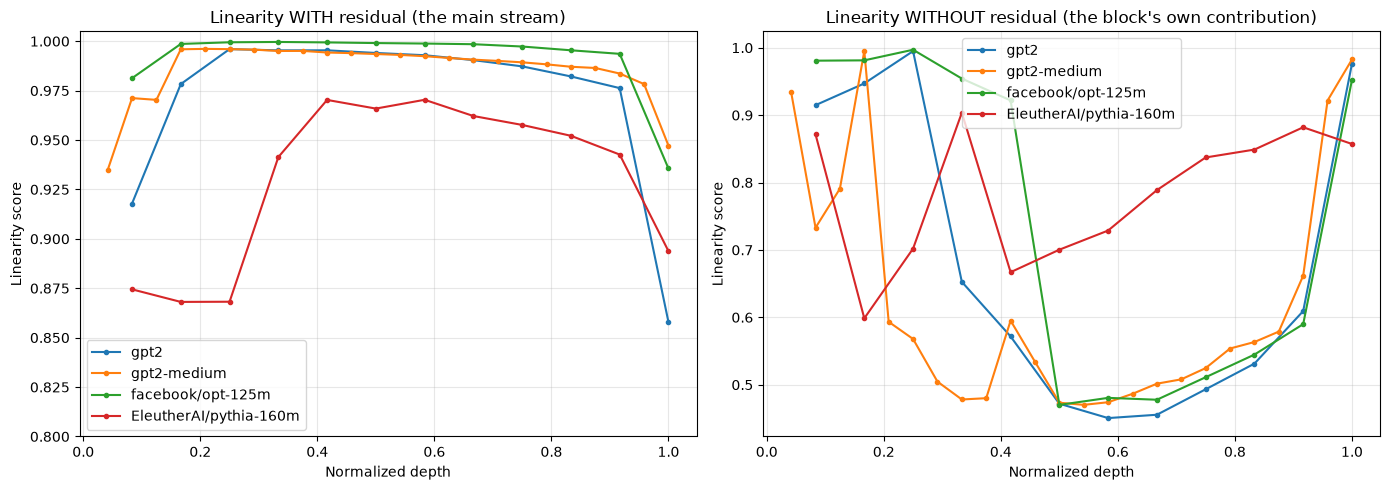

,model,layers,d,with residual,w/o residual
0,gpt2,12,768,0.9720,0.6724
1,gpt2-medium,24,1024,0.9854,0.6211
2,facebook/opt-125m,12,768,0.9914,0.7384
3,EleutherAI/pythia-160m,12,768,0.9306,0.7821


In [80]:
# Reproduction of Figure 1 of the paper.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name, res in results.items():
    n = res["n_layers"]
    depth = np.arange(1, n + 1) / n            # normalized depth, as in the paper
    axes[0].plot(depth, res["with_residual"], marker="o", markersize=3, label=model_name)
    axes[1].plot(depth, res["without_residual"], marker="o", markersize=3, label=model_name)

axes[0].set_title("Linearity WITH residual (the main stream)")
axes[1].set_title("Linearity WITHOUT residual (the block's own contribution)")
for ax in axes:
    ax.set_xlabel("Normalized depth")
    ax.set_ylabel("Linearity score")
    ax.grid(True, alpha=0.3)
    ax.legend()
axes[0].set_ylim(0.8, 1.005)

plt.tight_layout()
save_fig("fig1_linearity_profiles")
plt.show()

pd.DataFrame([
    {"model": k, "layers": v["n_layers"], "d": v["d_model"],
     "with residual": round(float(np.mean(v["with_residual"])), 4),
     "w/o residual": round(float(np.mean(v["without_residual"])), 4)}
    for k, v in results.items()
])

### What we see

All four models reproduce the paper. On the main stream every model climbs to a plateau near 0.99 in
the middle of the network and dips at both ends, with a mean of 0.970. Subtracting the residual
component drops the mean to 0.704, so the block itself is clearly not a linear operation - what is
linear is the mapping the residual connection produces around it.

The layer ranking confirms it numerically: GPT-2's least linear layers are its last (0.8775) and its
first (0.9447), exactly as the paper reports. The effect is also not tied to one implementation -
OPT-125M (0.9914), GPT-2 (0.9720) and Pythia-160M (0.9306) come from three independent codebases and
three different pretraining corpora, and all land in the same narrow band.

Pythia is the consistent outlier: lowest on the main stream and highest on the block's own
contribution. The two go together - its blocks write a larger update to the stream, but that update
is itself more linear. It is the only model here built on GPT-NeoX, which computes attention and MLP
in parallel and adds both at once rather than in two sequential steps. We flag this as a hypothesis;
we did not test it.

## 4.2 - Why is it so linear? The norm analysis

### What this experiment does

Section 1 argued that the score is high because each block adds only a small update to a large
stream. This experiment measures that claim directly. For every layer we compute:

- the ratio `||block output|| / ||residual stream||`
- the cosine similarity between consecutive hidden states

If the ratio is small and the cosine is near 1, then `h(i+1) ~ h(i)`, and the identity map is
trivially linear. This reproduces Figure 3 of the paper, and it is the difference between reporting
the number and explaining it.

The two measurements answer different questions, which is why we plot both. Cosine similarity asks
whether the vector *stayed in the same direction*. The linearity score asks whether the change is
*predictable by a fixed linear rule*. A layer could rotate every embedding substantially - low
cosine - while doing so with one consistent matrix, which is high linearity.

In [12]:
@torch.no_grad()
def norm_and_cosine_analysis(hidden_states):
    """For each consecutive pair: ||block output|| / ||stream||, and the cosine between them."""
    norm_ratios, cosines = [], []

    for i in range(len(hidden_states) - 1):
        X = hidden_states[i].to(torch.float32)
        Y = hidden_states[i + 1].to(torch.float32)
        block_out = Y - X                      # what the block itself added

        norm_ratios.append((block_out.norm(dim=1) / (X.norm(dim=1) + 1e-8)).mean().item())
        cosines.append(torch.nn.functional.cosine_similarity(X, Y, dim=1).mean().item())

    return norm_ratios, cosines

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

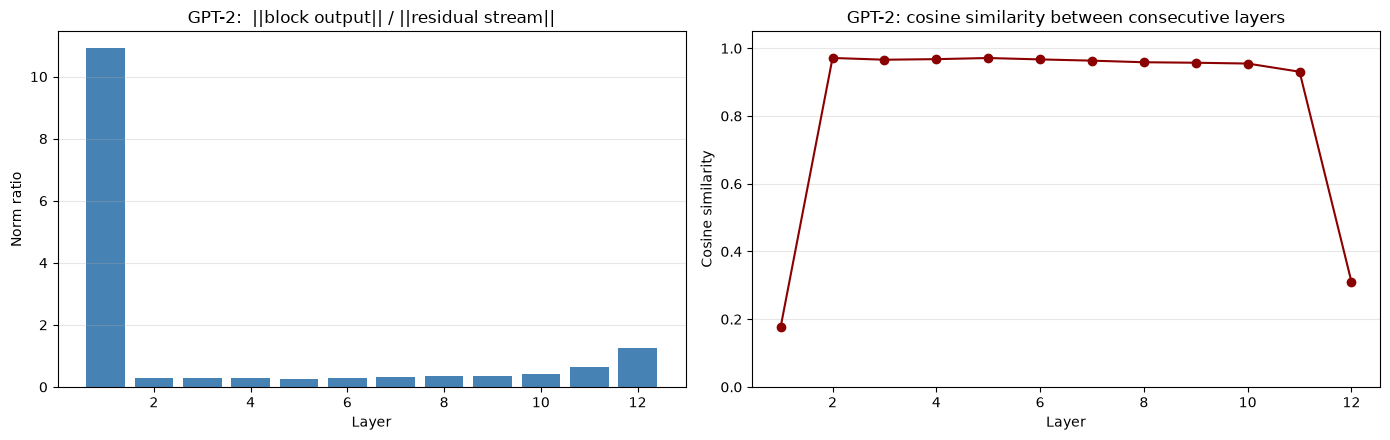

mean norm ratio       : 1.3028
mean cosine similarity: 0.8414


In [73]:
model, tokenizer = load_model("gpt2", causal=True)
hs_gpt2 = collect_hidden_states(model, make_batches(tokenizer, train_text))
del model
free_memory()

norm_ratios, cosines = norm_and_cosine_analysis(hs_gpt2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
layers = np.arange(1, len(norm_ratios) + 1)

axes[0].bar(layers, norm_ratios, color="steelblue")
axes[0].set_title("GPT-2:  ||block output|| / ||residual stream||")
axes[0].set_ylabel("Norm ratio")

axes[1].plot(layers, cosines, marker="o", color="darkred")
axes[1].set_title("GPT-2: cosine similarity between consecutive layers")
axes[1].set_ylabel("Cosine similarity")
axes[1].set_ylim(0, 1.05)

for ax in axes:
    ax.set_xlabel("Layer")
    ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
save_fig("fig2_norm_analysis")
plt.show()

print("mean norm ratio       :", round(float(np.mean(norm_ratios)), 4))
print("mean cosine similarity:", round(float(np.mean(cosines)), 4))

In [66]:
free_memory()

# A freshly initialised model, and the linearity before any training.
torch.manual_seed(SEED)
ft_model = AutoModelForSequenceClassification.from_pretrained("gpt2", num_labels=2)
ft_model.config.pad_token_id = tokenizer.pad_token_id
ft_model.config.use_cache = False
ft_model.to(device)
ft_model.eval()

# The same text is used for both measurements, so nothing else can explain the difference.
# The classification model is called directly: its output already carries hidden_states.
eval_batches = make_batches(tokenizer, train_text, n_seqs=16)

hs_before = collect_hidden_states(ft_model, eval_batches)
_, before_without_res = linearity_profile(hs_before)
print("mean linearity w/o residual BEFORE:", round(float(np.mean(before_without_res)), 4))

del hs_before
free_memory()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


mean linearity w/o residual BEFORE: 0.7373


In [71]:
# The mean over all layers is not representative, so it is broken down here.
# Layer 1 is an outlier: hidden_states[0] is the raw embedding output, whose norm is small,
# which makes the first block's contribution look disproportionately large. The final
# transition also differs, because HuggingFace applies the last LayerNorm before exposing
# the final hidden state, so that step is "block + LayerNorm" rather than a block.
# The interior layers are the ones the paper's Figure 3 describes.

print("norm ratio - mean over all layers      :", round(float(np.mean(norm_ratios)), 4))
print("norm ratio - median over all layers    :", round(float(np.median(norm_ratios)), 4))
print("norm ratio - mean over interior layers :", round(float(np.mean(norm_ratios[1:-1])), 4))
print("cosine     - mean over interior layers :", round(float(np.mean(cosines[1:-1])), 4))
print()
print("per layer:")
for i, (r, c) in enumerate(zip(norm_ratios, cosines), start=1):
    note = "   (embedding / final LayerNorm)" if i in (1, len(norm_ratios)) else ""
    print(f"  layer {i:2d}:  norm ratio = {r:7.3f}   cosine = {c:.4f}{note}")

norm ratio - mean over ALL layers      : 1.3028  <- dominated by layer 1, do not report this
norm ratio - median over ALL layers    : 0.3268
norm ratio - mean over interior layers : 0.3469
cosine     - mean over interior layers : 0.9609

per layer:
  layer  1:  norm ratio =  10.914   cosine = 0.1773   <- special (see comment above)
  layer  2:  norm ratio =   0.290   cosine = 0.9714
  layer  3:  norm ratio =   0.284   cosine = 0.9662
  layer  4:  norm ratio =   0.276   cosine = 0.9679
  layer  5:  norm ratio =   0.260   cosine = 0.9712
  layer  6:  norm ratio =   0.281   cosine = 0.9671
  layer  7:  norm ratio =   0.306   cosine = 0.9634
  layer  8:  norm ratio =   0.347   cosine = 0.9587
  layer  9:  norm ratio =   0.367   cosine = 0.9573
  layer 10:  norm ratio =   0.423   cosine = 0.9549
  layer 11:  norm ratio =   0.634   cosine = 0.9308
  layer 12:  norm ratio =   1.251   cosine = 0.3103   <- special (see comment above)


### What we see

For the ten interior layers the block output has a norm of 0.347 relative to the stream it joins, at
a cosine similarity of 0.961. Each block adds roughly a third of the stream's norm and barely rotates
it, so the next hidden state is mostly the previous one - and the identity map is trivially linear.
This is the paper's Figure 3, reproduced, and it is the mechanism behind the 0.97.

Two layers have to be excluded before the average means anything. Layer 1 has a ratio of 10.9 because
`hidden_states[0]` is the raw embedding output, whose norm is small, so the first block's contribution
looks enormous beside it. Layer 12 is also special: HuggingFace applies the final LayerNorm before
exposing the last hidden state, so that step is "block + LayerNorm" rather than a block - which is why
its cosine collapses to 0.31 while every interior layer stays above 0.93. The raw mean over all layers
is 1.3028 and is not meaningful.

## 4.3 - Does fine-tuning change the linearity?

### What this experiment does

The paper reports that pretraining slowly *decreases* linearity while fine-tuning *increases* it -
every entry of their Table 1 is positive. This is counter-intuitive: you would expect fine-tuning to
add task-specific structure, not to make the layers simpler.

The experiment is:

1. measure GPT-2's linearity **without residual** on WikiText,
2. fine-tune GPT-2 for a couple of epochs on a binary classification task,
3. measure again **on exactly the same text**,
4. look at the sign of the difference.

This is the only part of the notebook that trains anything. The two cells below first search for a
learning rate, then train with the best one.

### On the hyperparameters

The experiment is about the *change* in linearity, not about winning the task - but a run that does
not learn anything is not a fine-tune, so the settings do have to be reasonable. The defaults:

| Setting | Value | Why |
|---|---|---|
| task | SST-2 | our first attempt used BoolQ, like the paper. GPT-2-small never beat the majority baseline on it (0.6175 vs 0.622) - it only learned the class prior. SST-2 is single-sentence sentiment, its validation set is balanced, and GPT-2-small reaches 85-90%, so any gain is unambiguous. |
| learning rate | searched over 2e-5, 5e-5, 1e-4 | the standard range for a pretrained transformer with a freshly initialised head. Below it the head barely moves in the few hundred steps we can afford; above it the pretrained body gets destroyed. |
| batch size | 4, with gradient accumulation to an effective 16 | 4 GB cannot hold more. Accumulation gives the stability of a larger batch at the memory cost of a small one. |
| epochs | 3 on 6000 examples | about 1100 optimizer steps. Our first attempt used 600 examples for one epoch - 38 steps - which is far too few to train a randomly initialised classification head, so every candidate scored at chance and the search was meaningless. |
| max length | 64 tokens | SST-2 sentences are short; this roughly doubles the speed over 128. |
| scheduler | linear decay with 10% warmup | warmup matters: the freshly initialised classification head produces large gradients in the first steps that can wreck the pretrained body. |
| weight decay | 0.01 | standard. |
| grad clipping | 1.0 | GPT-2 fine-tuning is unstable without it. |
| precision | AMP (fp16 autocast + GradScaler) | roughly halves memory and speeds it up; the GradScaler is what keeps fp16 gradients from underflowing. |

**How we know the experiment is valid.** A classifier that learns nothing about the input but
matches the class frequencies scores exactly the majority-class rate. The cells below print that
baseline and compare the final accuracy against it: if the model does not beat it clearly, the
layers may have become more linear through *representation collapse* rather than task
specialisation, and the delta must not be reported. This check is the difference between a
result and an artifact.

In [13]:
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup


def load_classification_task():
    """
    Loads a binary text-classification task. SST-2 is used because GPT-2-small does not
    exceed the majority-class baseline on BoolQ; the experiment measures the change in
    linearity, so the task only has to be one the model can actually learn.
    """
    boolq_text = lambda ex: ex["question"] + " passage: " + ex["passage"]
    sst2_text = lambda ex: ex["sentence"]

    candidates = [
        ("stanfordnlp/sst2", None, sst2_text),
        ("aps/super_glue", "boolq", boolq_text),
        ("super_glue", "boolq", boolq_text),
        ("google/boolq", None, boolq_text),
    ]
    for name, config, text_fn in candidates:
        try:
            ds = load_dataset(name, config) if config else load_dataset(name)
            print(f"loaded: {name}" + (f" [{config}]" if config else ""))
            return ds, text_fn
        except Exception as e:
            print(f"   could not load {name}: {type(e).__name__}")
    raise RuntimeError("no classification dataset could be loaded")


task_ds, task_text_fn = load_classification_task()


class TextClassificationDataset(Dataset):
    """Tokenizes the examples on the fly."""

    def __init__(self, hf_split, text_fn, tokenizer, max_len=128, limit=None):
        self.examples = list(hf_split)[:limit] if limit else list(hf_split)
        self.text_fn, self.tokenizer, self.max_len = text_fn, tokenizer, max_len

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]
        enc = self.tokenizer(self.text_fn(ex), truncation=True, max_length=self.max_len,
                             padding="max_length", return_tensors="pt", verbose=False)
        return {"input_ids": enc["input_ids"][0],
                "attention_mask": enc["attention_mask"][0],
                "labels": torch.tensor(int(ex["label"]))}

loaded: stanfordnlp/sst2


In [14]:
# ---- hyperparameters -------------------------------------------------------
FT_BATCH = 4           # physical batch, limited by VRAM
FT_ACCUM = 4           # gradient accumulation -> effective batch of 16
FT_EPOCHS = 3
FT_MAX_LEN = 64
FT_WEIGHT_DECAY = 0.01
FT_WARMUP_FRAC = 0.1
FT_USE_AMP = torch.cuda.is_available()

LR_CANDIDATES = [2e-5, 5e-5, 1e-4]
SEARCH_EPOCHS = 2      # epochs per candidate in the learning-rate search

TRAIN_LIMIT = 6000    # examples for the final run
SEARCH_LIMIT = 2500     # smaller subset for the learning-rate search
VAL_LIMIT = 872


@torch.no_grad()
def evaluate(model, loader):
    """Accuracy on a loader."""
    model.eval()
    correct = total = 0
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        with torch.autocast("cuda", dtype=torch.float16, enabled=FT_USE_AMP):
            logits = model(input_ids=batch["input_ids"],
                           attention_mask=batch["attention_mask"]).logits
        correct += (logits.argmax(-1) == batch["labels"]).sum().item()
        total += batch["labels"].size(0)
    return correct / max(total, 1)


def finetune(model, train_loader, val_loader, lr, epochs=FT_EPOCHS, quiet=False):
    """
    Fine-tunes a sequence-classification model with linear warmup and decay, gradient
    accumulation and mixed precision.
    """
    # Standard practice: no weight decay on biases or LayerNorm parameters.
    decay, no_decay = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        (no_decay if (p.ndim == 1 or name.endswith(".bias")) else decay).append(p)

    optimizer = torch.optim.AdamW(
        [{"params": decay, "weight_decay": FT_WEIGHT_DECAY},
         {"params": no_decay, "weight_decay": 0.0}], lr=lr)

    total_steps = math.ceil(len(train_loader) / FT_ACCUM) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, int(FT_WARMUP_FRAC * total_steps), total_steps)
    scaler = torch.amp.GradScaler("cuda", enabled=FT_USE_AMP)

    history = []
    for epoch in range(epochs):
        model.train()
        running = 0.0
        optimizer.zero_grad(set_to_none=True)

        iterator = train_loader if quiet else tqdm(train_loader, desc=f"lr={lr:g} epoch {epoch+1}/{epochs}")
        for step, batch in enumerate(iterator):
            batch = {k: v.to(device) for k, v in batch.items()}

            with torch.autocast("cuda", dtype=torch.float16, enabled=FT_USE_AMP):
                loss = model(**batch).loss / FT_ACCUM

            scaler.scale(loss).backward()
            running += loss.item() * FT_ACCUM

            if (step + 1) % FT_ACCUM == 0 or (step + 1) == len(train_loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)

        val_acc = evaluate(model, val_loader)
        history.append({"epoch": epoch + 1, "loss": running / len(train_loader), "val_acc": val_acc})
        if not quiet:
            print(f"   epoch {epoch+1}: loss={history[-1]['loss']:.4f}  val_acc={val_acc:.4f}")

    model.eval()
    return history

### Learning-rate search

Each candidate gets a short run on a small subset, and we keep the one with the best validation
accuracy. This is deliberately cheap - a few minutes - because we only need a learning rate that
clearly *works*, not the last half percent of accuracy.

### The actual experiment: measure, fine-tune, measure again

In [62]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

val_split_name = "validation" if "validation" in task_ds else "test"

search_ds = TextClassificationDataset(task_ds["train"], task_text_fn, tokenizer,
                                      FT_MAX_LEN, limit=SEARCH_LIMIT)
val_ds = TextClassificationDataset(task_ds[val_split_name], task_text_fn, tokenizer,
                                   FT_MAX_LEN, limit=VAL_LIMIT)

search_loader = DataLoader(search_ds, batch_size=FT_BATCH, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=FT_BATCH * 2, shuffle=False)

# A classifier that learns only the class prior scores exactly the majority-class rate.
# The fine-tuned accuracy is compared against it, since a delta measured on a model that
# did not learn the task cannot be interpreted.
val_labels = [int(ex["label"]) for ex in val_ds.examples]
MAJORITY = float(max(np.mean(val_labels), 1 - np.mean(val_labels)))

print(f"search on {len(search_ds)} examples, validating on {len(val_ds)}")
print(f"majority-class baseline on this validation set: {MAJORITY:.4f}\n")

search_results = []
for lr in LR_CANDIDATES:
    torch.manual_seed(SEED)          # identical initialisation for every candidate
    m = AutoModelForSequenceClassification.from_pretrained("gpt2", num_labels=2)
    m.config.pad_token_id = tokenizer.pad_token_id
    m.config.use_cache = False
    m.to(device)

    hist = finetune(m, search_loader, val_loader, lr=lr, epochs=SEARCH_EPOCHS)
    search_results.append({"lr": lr, "val_acc": hist[-1]["val_acc"], "loss": hist[-1]["loss"]})

    del m
    free_memory()

search_df = pd.DataFrame(search_results).sort_values("val_acc", ascending=False)
BEST_LR = float(search_df.iloc[0]["lr"])
print(f"\nbest learning rate: {BEST_LR:g}")
search_df

search on 2500 examples, validating on 872
majority-class baseline on this validation set: 0.5092
a real fine-tune has to beat this clearly



Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


lr=2e-05 epoch 1/2:   0%|          | 0/625 [00:00<?, ?it/s]

C:\Users\Dvir\AppData\Local\Temp\ipykernel_20836\1128657108.py:76: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


...

lr=0.0001 epoch 1/2:   0%|          | 0/625 [00:00<?, ?it/s]

   epoch 1: loss=0.8173  val_acc=0.8647


lr=0.0001 epoch 2/2:   0%|          | 0/625 [00:00<?, ?it/s]

   epoch 2: loss=0.2534  val_acc=0.8761

best learning rate: 5e-05


,lr,val_acc,loss
1,0.00005,0.876147,0.277436
2,0.00010,0.876147,0.253352
0,0.00002,0.852064,0.358373


In [64]:
train_ds = TextClassificationDataset(task_ds["train"], task_text_fn, tokenizer,
                                     FT_MAX_LEN, limit=TRAIN_LIMIT)
train_loader = DataLoader(train_ds, batch_size=FT_BATCH, shuffle=True)

print(f"fine-tuning on {len(train_ds)} examples, lr={BEST_LR:g}, "
      f"batch={FT_BATCH}x{FT_ACCUM}={FT_BATCH*FT_ACCUM} effective\n")

ft_history = finetune(ft_model, train_loader, val_loader, lr=BEST_LR, epochs=FT_EPOCHS)

# The linearity after fine-tuning, measured on exactly the same text.
hs_after = collect_hidden_states(ft_model, eval_batches)
_, after_without_res = linearity_profile(hs_after)
print("\nmean linearity w/o residual AFTER :", round(float(np.mean(after_without_res)), 4))

delta = np.array(after_without_res) - np.array(before_without_res)
print("delta (after - before)            :", round(float(delta.mean()), 4),
      "  (the paper reports a positive value)")

# A delta measured on a model that only learned the class prior would reflect
# representation collapse rather than task specialisation, so the accuracy is checked
# against the majority-class baseline before the delta is reported.
final_acc = ft_history[-1]["val_acc"]
print(f"\nvalidation accuracy {final_acc:.4f}  vs  majority baseline {MAJORITY:.4f}")

if final_acc < MAJORITY + 0.05:
    print("The model did not clearly exceed the baseline - this delta is not interpretable.")
else:
    print("The model learned the task, so the delta reflects fine-tuning.")

del ft_model, hs_after
free_memory()

fine-tuning on 6000 examples, lr=5e-05, batch=4x4=16 effective



lr=5e-05 epoch 1/3:   0%|          | 0/1500 [00:00<?, ?it/s]

C:\Users\Dvir\AppData\Local\Temp\ipykernel_20836\1128657108.py:76: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


   epoch 1: loss=0.7304  val_acc=0.8394


lr=5e-05 epoch 2/3:   0%|          | 0/1500 [00:00<?, ?it/s]

   epoch 2: loss=0.2563  val_acc=0.9037


lr=5e-05 epoch 3/3:   0%|          | 0/1500 [00:00<?, ?it/s]

   epoch 3: loss=0.1463  val_acc=0.9002

mean linearity w/o residual AFTER : 0.7216
delta (after - before)            : -0.0157  <- the paper predicts POSITIVE

validation accuracy 0.9002  vs  majority baseline 0.5092
OK - the model learned the task, so the delta reflects fine-tuning.


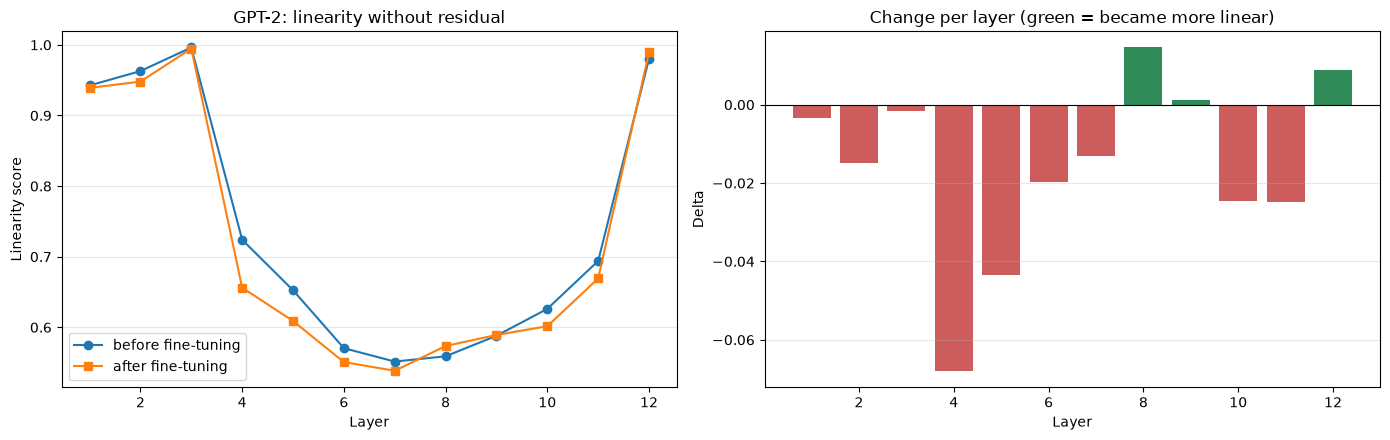

In [76]:
layers = np.arange(1, len(before_without_res) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(layers, before_without_res, marker="o", label="before fine-tuning")
axes[0].plot(layers, after_without_res, marker="s", label="after fine-tuning")
axes[0].set_title("GPT-2: linearity without residual")
axes[0].set_ylabel("Linearity score")
axes[0].legend()

axes[1].bar(layers, delta, color=["seagreen" if d > 0 else "indianred" for d in delta])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Change per layer (green = became more linear)")
axes[1].set_ylabel("Delta")

for ax in axes:
    ax.set_xlabel("Layer")
    ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
save_fig("fig3_finetuning_delta")
plt.show()

### What we see

**We did not reproduce the direction reported in Table 1.** With a fine-tune that genuinely learned
its task - SST-2, validation accuracy 0.9002 against a balanced 0.5092 baseline - the mean delta was
**-0.0157**, and nine of twelve layers became less linear.

Our earlier attempt on BoolQ produced **+0.1106**, apparently confirming the paper. But that model
never beat its majority baseline (0.6175 against 0.622), and its final loss of 0.6511 is almost
exactly the entropy of the class prior (0.663) - so it had learned P(y) and nothing about the input.
A collapsed representation converges towards a near-constant output, which any linear map predicts
perfectly, so the score rises for the wrong reason.

The paper's positive direction appeared in our experiments only in that degenerate case. We state
this carefully rather than as a refutation - the paper fine-tunes larger models on different tasks,
and we ran a single seed. But the contrast between our two runs carries a concrete recommendation:
a Table 1-style linearity delta cannot be interpreted without the task accuracy reported beside it.

## 4.4 - Depth pruning of the most linear layers

### What this experiment does

This is the experiment that decides whether the linearity score is *useful* or only descriptive.

The reasoning: if a layer performs an almost perfectly linear transformation, it adds little that
the rest of the network cannot already express. So deleting exactly those layers should cost less
than deleting others.

We rank GPT-2's layers by their linearity score, then compare three deletion strategies at
k = 1, 2, 3, 4 layers removed:

- the **k most linear** layers - the paper's method
- **k random** layers, averaged over 3 seeds - the fair baseline
- the **last k** layers - a common cheap heuristic

The metric is perplexity on the WikiText-2 test set, against the full model as reference. If the
"most linear" curve is the lowest of the three, the score has predictive content.

**A note on pruning a HuggingFace model:** deleting entries from the block list is not enough. The
layer count also lives in the config, and the key-value cache assumes the original depth. Both have
to be updated or the forward pass breaks in a confusing place.

In [15]:
@torch.no_grad()
def compute_perplexity(model, tokenizer, text, seq_len=512, n_seqs=40):
    """exp(mean token-level cross entropy) over non-overlapping windows."""
    needed = seq_len * n_seqs
    ids = tokenizer(text[: needed * 8], return_tensors="pt", verbose=False).input_ids[0]

    if ids.numel() < needed:
        n_seqs = max(1, ids.numel() // seq_len)
        needed = seq_len * n_seqs
    ids = ids[:needed].view(n_seqs, seq_len)

    total_nll = total_tokens = 0
    model.eval()

    for i in range(n_seqs):
        input_ids = ids[i:i+1].to(device)
        out = model(input_ids, labels=input_ids)
        n_pred = input_ids.shape[1] - 1          # the loss is already averaged over these
        total_nll += out.loss.float().item() * n_pred
        total_tokens += n_pred

    return math.exp(total_nll / total_tokens)


def find_blocks(model):
    """
    Finds the ModuleList of transformer blocks and returns (blocks, parent, attribute_name).
    Model families name this attribute differently and the names change between library
    versions, so the known paths are tried first, falling back to the longest ModuleList.
    """
    known = ["transformer.h", "model.decoder.layers", "gpt_neox.layers",
             "model.layers", "bert.encoder.layer", "encoder.layer"]

    for path in known:
        obj, parts = model, path.split(".")
        try:
            for part in parts[:-1]:
                obj = getattr(obj, part)
            blocks = getattr(obj, parts[-1])
            if isinstance(blocks, nn.ModuleList) and len(blocks) > 0:
                return blocks, obj, parts[-1]
        except AttributeError:
            continue

    best = None
    for name, module in model.named_modules():
        if isinstance(module, nn.ModuleList) and len(module) > 0:
            if best is None or len(module) > len(best[0]):
                best = (module, name)
    if best is None:
        raise ValueError("could not find the transformer blocks in this model")

    blocks, name = best
    parent, parts = model, name.split(".")
    for part in parts[:-1]:
        parent = getattr(parent, part)
    return blocks, parent, parts[-1]


def get_blocks(model):
    return find_blocks(model)[0]


def prune_layers(model, layers_to_remove):
    """Removes the given layer indices, in place."""
    blocks, parent, attr = find_blocks(model)
    remove = {int(i) for i in layers_to_remove}
    kept = [b for i, b in enumerate(blocks) if i not in remove]
    setattr(parent, attr, nn.ModuleList(kept))

    # the config records the depth and the forward pass reads it
    for attr_name in ["n_layer", "num_hidden_layers", "num_layers"]:
        if hasattr(model.config, attr_name):
            setattr(model.config, attr_name, len(kept))

    model.config.use_cache = False    # the KV cache assumes the original depth
    return model

In [17]:
# the reference point, and the ranking of GPT-2's layers by linearity
model, tokenizer = load_model("gpt2", causal=True, dtype=torch.float32)

baseline_ppl = compute_perplexity(model, tokenizer, test_text)
print(f"GPT-2 full model perplexity: {baseline_ppl:.3f}\n")

hs = collect_hidden_states(model, make_batches(tokenizer, train_text, n_seqs=16))
gpt2_with_res, _ = linearity_profile(hs)

ranking = np.argsort(gpt2_with_res)[::-1]        # most linear first
print("layers, most linear first:")
for rank, layer_idx in enumerate(ranking):
    print(f"  {rank+1:2d}. layer {layer_idx:2d}   score = {gpt2_with_res[layer_idx]:.4f}")

del model, hs
free_memory()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


GPT-2 full model perplexity: 37.574

layers, most linear first:
   1. layer  2   score = 0.9971
   2. layer  3   score = 0.9963
   3. layer  4   score = 0.9963
   4. layer  5   score = 0.9952
   5. layer  6   score = 0.9942
   6. layer  7   score = 0.9923
   7. layer  8   score = 0.9897
   8. layer  9   score = 0.9859
   9. layer  1   score = 0.9848
  10. layer 10   score = 0.9820
  11. layer  0   score = 0.9447
  12. layer 11   score = 0.8775


In [18]:
def evaluate_pruned(layers_to_remove, dtype=torch.float32):
    """Loads a fresh GPT-2, removes the given layers, returns the perplexity."""
    model, tokenizer = load_model("gpt2", causal=True, dtype=dtype)
    prune_layers(model, layers_to_remove)
    ppl = compute_perplexity(model, tokenizer, test_text)
    del model
    free_memory()
    return ppl


K_VALUES = [1, 2, 3, 4]
n_layers = len(gpt2_with_res)
pruning_results = {"k": [], "most_linear": [], "random": [], "last": []}

for k in K_VALUES:
    most_linear = [int(i) for i in ranking[:k]]
    last_layers = list(range(n_layers - k, n_layers))

    ppl_linear = evaluate_pruned(most_linear)

    random_ppls = []
    for seed in [0, 1, 2]:
        rng = np.random.RandomState(seed)
        random_ppls.append(evaluate_pruned(list(rng.choice(n_layers, size=k, replace=False))))
    ppl_random = float(np.mean(random_ppls))

    ppl_last = evaluate_pruned(last_layers)

    pruning_results["k"].append(k)
    pruning_results["most_linear"].append(ppl_linear)
    pruning_results["random"].append(ppl_random)
    pruning_results["last"].append(ppl_last)

    print(f"k={k}  most linear {most_linear}: {ppl_linear:9.2f} | "
          f"random: {ppl_random:9.2f} | last: {ppl_last:9.2f}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

k=4  most linear [2, 3, 4, 5]:    482.04 | random:    418.76 | last:   2746.53


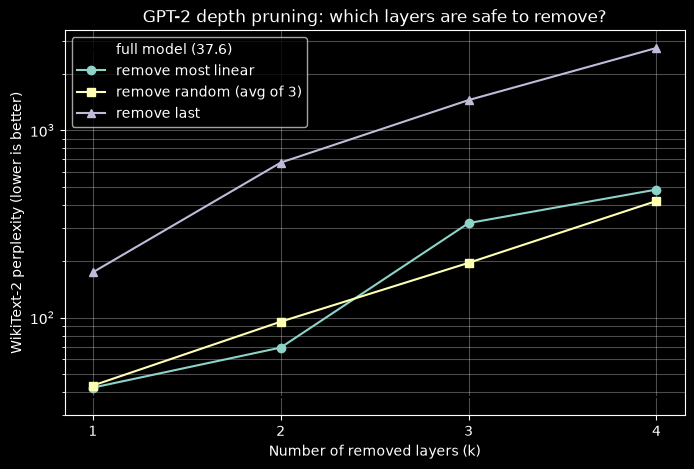

,most_linear,random,last
k,,,
1,42.240132,43.327784,174.276503
2,69.117460,94.999563,671.072102
3,319.129708,195.771284,1447.164174
4,482.035722,418.760833,2746.534743


In [19]:
plt.figure(figsize=(8, 5))
plt.axhline(baseline_ppl, color="black", linestyle="--", label=f"full model ({baseline_ppl:.1f})")
plt.plot(pruning_results["k"], pruning_results["most_linear"], marker="o", label="remove most linear")
plt.plot(pruning_results["k"], pruning_results["random"], marker="s", label="remove random (avg of 3)")
plt.plot(pruning_results["k"], pruning_results["last"], marker="^", label="remove last")

plt.xlabel("Number of removed layers (k)")
plt.ylabel("WikiText-2 perplexity (lower is better)")
plt.title("GPT-2 depth pruning: which layers are safe to remove?")
plt.xticks(pruning_results["k"])
plt.yscale("log")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.ylim(bottom=30)
save_fig("fig4_pruning_comparison")
plt.show()

pd.DataFrame(pruning_results).set_index("k")

### What we see

Removing the most linear layers is cheaper than the baselines at k = 1 and k = 2, and then **loses to
random removal** at k = 3 and k = 4. Removing the last layers is catastrophic at every k, which is
expected since they feed the output head directly.

The reversal has an explanation that the top-k rule ignores. GPT-2's four most linear layers are 2, 3,
4 and 5 - they are adjacent. Deleting them removes a whole contiguous stage of computation, while
random deletions spread the damage across the depth. So the linearity score is a good guide for
removing one or two layers, but selecting the top k greedily is not, because the ranking says nothing
about how the chosen layers interact. A selection rule that penalised adjacency would likely do
better; we did not test one.

Note also that our models are much smaller than the paper's, so they have less redundancy to give
away in the first place.

## 4.5 - Replacing a pruned layer with a linear approximation

### What this experiment does

Instead of deleting a linear layer, replace it with the linear map that best imitates it.

The paper trains this replacement with a layer-wise distillation loss. We use a shortcut: when the
target is a linear map, the distillation objective **is** a least-squares problem, and least squares
has an exact solution. So we collect the layer's inputs and outputs on calibration text and solve
one system for `h -> hW + b`. Seconds instead of hours of training, and it converges to where
gradient descent would have gone anyway.

Two details:

- **We fit an affine map, not just a matrix.** The block's output has a non-zero mean, so the bias
  term makes the approximation noticeably better for free. We append a column of ones to `X` so the
  bias solves inside the same system.
- **When we replace several layers at once**, each map was fitted on the *original* model's
  activations, so the later ones see a slightly shifted input distribution. The paper's joint
  distillation handles that; ours is an approximation and we say so.

In [37]:
class LinearBlock(nn.Module):
    """
    A drop-in replacement for a whole transformer block: instead of attention and an MLP it
    applies a single learned affine map, h -> h @ W + b.
    """

    def __init__(self, W, b, returns_tuple=True):
        super().__init__()
        self.W = nn.Parameter(W)
        self.b = nn.Parameter(b)
        self.returns_tuple = returns_tuple

    def forward(self, hidden_states, *args, **kwargs):
        out = hidden_states @ self.W + self.b
        return (out,) if self.returns_tuple else out


@torch.no_grad()
def fit_linear_replacement(X, Y, ridge=1e-4):
    """
    Solves min_{W,b} ||X @ W + b - Y||^2 in closed form, by appending a column of ones to X
    so the bias is part of the same solve. Returns W, b and the R^2 of the fit.
    """
    X = X.to(torch.float64)
    Y = Y.to(torch.float64)

    X_aug = torch.cat([X, torch.ones(X.shape[0], 1, dtype=torch.float64)], dim=1)
    XtX = X_aug.T @ X_aug
    sol = torch.linalg.solve(XtX + ridge * torch.eye(XtX.shape[0], dtype=torch.float64),
                             X_aug.T @ Y)

    pred = X_aug @ sol
    r2 = float(1 - ((pred - Y) ** 2).sum() / ((Y - Y.mean(dim=0)) ** 2).sum())
    return sol[:-1].to(torch.float32), sol[-1].to(torch.float32), r2


@torch.no_grad()
def block_returns_tuple(model, layer_idx):
    """
    Older transformers versions return a tuple from a block, newer ones return a bare tensor,
    and the replacement must match. A forward hook on the original block during one real
    forward pass reports exactly what the surrounding code receives.
    """
    blocks = get_blocks(model)
    seen = {}

    def hook(module, args, output):
        seen["is_tuple"] = isinstance(output, tuple)

    handle = blocks[layer_idx].register_forward_hook(hook)
    try:
        model(torch.zeros(1, 8, dtype=torch.long, device=device))
    finally:
        handle.remove()
    return seen.get("is_tuple", True)


def replace_layer_with_linear(model, layer_idx, X, Y, verbose=True):
    """Replaces block `layer_idx` with the best affine approximation fitted on X -> Y."""
    W, b, r2 = fit_linear_replacement(X, Y)
    if verbose:
        print(f"   layer {layer_idx}: linear approximation R^2 = {r2:.4f}")

    returns_tuple = block_returns_tuple(model, layer_idx)
    get_blocks(model)[layer_idx] = LinearBlock(W.to(device), b.to(device), returns_tuple).to(device)
    return model, r2

In [38]:
# calibration activations, collected once from the original model
calib_model, tokenizer = load_model("gpt2", causal=True, dtype=torch.float32)
calib_hs = collect_hidden_states(calib_model, make_batches(tokenizer, train_text, n_seqs=16))
del calib_model
free_memory()

replacement_results = {"k": [], "deleted": [], "linear_replaced": [], "mean_r2": []}

for k in K_VALUES:
    layers = [int(i) for i in ranking[:k]]
    print(f"\nk={k}, layers {layers}")

    ppl_del = evaluate_pruned(layers)

    model, tokenizer = load_model("gpt2", causal=True, dtype=torch.float32)
    r2s = []
    for layer_idx in layers:
        _, r2 = replace_layer_with_linear(model, layer_idx,
                                          calib_hs[layer_idx], calib_hs[layer_idx + 1])
        r2s.append(r2)
    ppl_lin = compute_perplexity(model, tokenizer, test_text)
    del model
    free_memory()

    replacement_results["k"].append(k)
    replacement_results["deleted"].append(ppl_del)
    replacement_results["linear_replaced"].append(ppl_lin)
    replacement_results["mean_r2"].append(float(np.mean(r2s)))

    print(f"   deleted: {ppl_del:9.2f}   |   linear replacement: {ppl_lin:9.2f}")

del calib_hs
free_memory()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]


k=1, layers [2]


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

   layer 2: linear approximation R^2 = 0.9971
   deleted:     42.24   |   linear replacement:     53.18

k=2, layers [2, 3]


...

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

   layer 2: linear approximation R^2 = 0.9971
   layer 3: linear approximation R^2 = 0.9963
   layer 4: linear approximation R^2 = 0.9963
   deleted:    319.13   |   linear replacement:    148.34

k=4, layers [2, 3, 4, 5]


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

   layer 2: linear approximation R^2 = 0.9971
   layer 3: linear approximation R^2 = 0.9963
   layer 4: linear approximation R^2 = 0.9963
   layer 5: linear approximation R^2 = 0.9952
   deleted:    482.04   |   linear replacement:    161.32


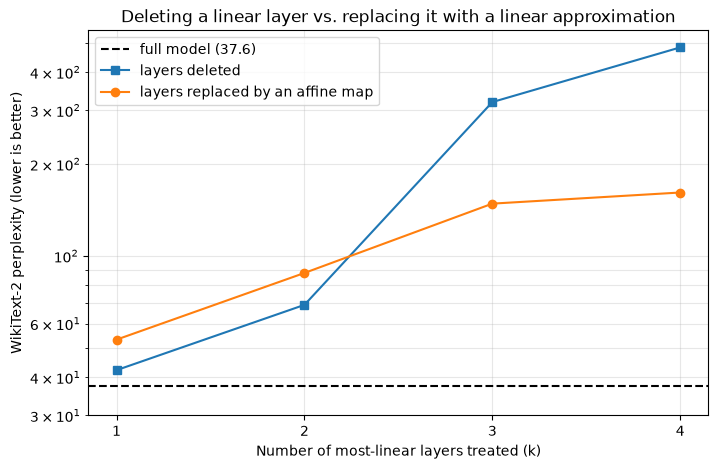

,deleted,linear_replaced,mean_r2
k,,,
1,42.240132,53.177929,0.997069
2,69.117460,87.922896,0.996708
3,319.129708,148.336213,0.996570
4,482.035722,161.319726,0.996228


In [84]:
plt.figure(figsize=(8, 5))
plt.axhline(baseline_ppl, color="black", linestyle="--", label=f"full model ({baseline_ppl:.1f})")
plt.plot(replacement_results["k"], replacement_results["deleted"], marker="s", label="layers deleted")
plt.plot(replacement_results["k"], replacement_results["linear_replaced"], marker="o",
         label="layers replaced by an affine map")

plt.xlabel("Number of most-linear layers treated (k)")
plt.ylabel("WikiText-2 perplexity (lower is better)")
plt.title("Deleting a linear layer vs. replacing it with a linear approximation")
plt.xticks(replacement_results["k"])
plt.yscale("log")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.ylim(bottom=30)
save_fig("fig5_linear_replacement")
plt.show()

pd.DataFrame(replacement_results).set_index("k")

### What we see

The two curves cross. For k = 1 and k = 2 the affine replacement is **worse** than simply deleting the
layer (42.2 to 53.2, and 69.1 to 87.9) - the network absorbs a missing layer well, and injecting an
imperfect approximation only adds error. For k = 3 and k = 4, where deletion becomes catastrophic, the
linear map recovers most of the damage: at k = 4 it cuts perplexity from **482 to 161**, a factor of
three.

So the paper's claim holds exactly where the technique is actually needed. The fitted maps have R^2
above 0.996 throughout, consistent with the linearity scores of the layers they replace.

One caveat: when several layers are replaced at once, each map was fitted on the original model's
activations, so the later ones see a slightly shifted input distribution. The paper's joint
distillation handles this; our closed-form version does not.

---

# Section 5 - Limitations of the Paper's Solution, and the Modifications We Examined

## What this section does

Two of these are experiments we ran, not just commentary:

- **5.1** tests a limitation the authors state themselves: they only studied decoders.
- **5.2** tests a property of their *metric* that the paper never discusses, and which affects how
  our own section 4.1 numbers should be read.
- **5.3** collects the limitations we can argue for but did not test.

## 5.1 - Are encoders secretly linear too?

### What this experiment does

In their Limitations section the authors write:

> "Our analysis predominantly focuses on transformer decoders, thus the generalizability of our
> findings to encoder-only or encoder-decoder architectures may be limited."

But the title says *transformer*, and the mechanism they give in section 4.2 - a small contribution
added to a large residual stream - has nothing to do with causal masking. BERT and RoBERTa have
exactly the same residual structure.

So we run the identical measurement on two encoders and plot them next to the decoders. Either the
effect appears in encoders too, and the paper's framing is too narrow; or it does not, and there is
something genuinely decoder-specific worth naming. Both outcomes are informative.

In [40]:
encoder_results = {}

for model_name in ENCODER_MODELS:
    print(f"\n=== {model_name} ===")
    model, tokenizer = load_model(model_name, causal=False)
    batches = make_batches(tokenizer, train_text, seq_len=128, n_seqs=N_SEQS)

    hidden_states = collect_hidden_states(model, batches)
    with_res, without_res = linearity_profile(hidden_states)
    ratios, _ = norm_and_cosine_analysis(hidden_states)

    encoder_results[model_name] = {
        "with_residual": with_res,
        "without_residual": without_res,
        "norm_ratios": ratios,
        "n_layers": len(with_res),
        "d_model": hidden_states[0].shape[1],
    }
    print(f"mean linearity WITH residual   : {np.mean(with_res):.4f}")
    print(f"mean linearity WITHOUT residual: {np.mean(without_res):.4f}")
    print(f"mean norm ratio                : {np.mean(ratios):.4f}")

    del model, hidden_states, batches
    free_memory()


=== bert-base-uncased ===


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


mean linearity WITH residual   : 0.9214
mean linearity WITHOUT residual: 0.6652
mean norm ratio                : 0.4684

=== roberta-base ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


mean linearity WITH residual   : 0.9285
mean linearity WITHOUT residual: 0.6924
mean norm ratio                : 0.3965


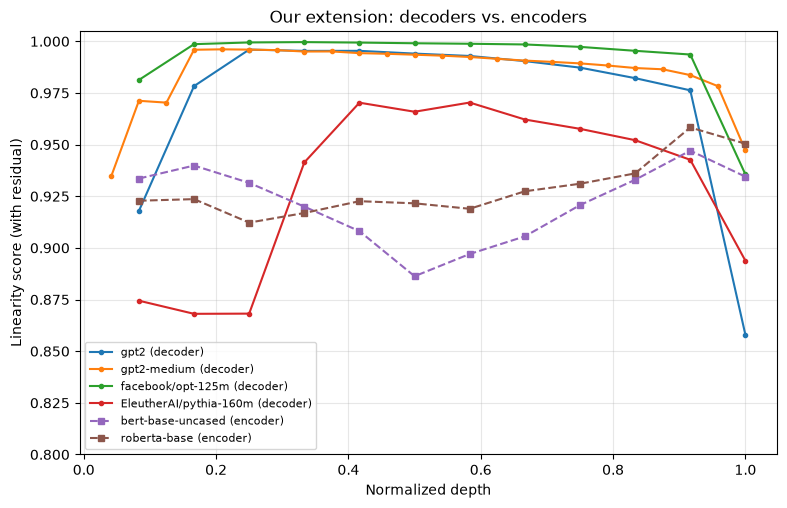

In [79]:
plt.figure(figsize=(9, 5.5))

for model_name, res in results.items():
    n = res["n_layers"]
    plt.plot(np.arange(1, n + 1) / n, res["with_residual"],
             marker="o", markersize=3, linestyle="-", label=f"{model_name} (decoder)")

for model_name, res in encoder_results.items():
    n = res["n_layers"]
    plt.plot(np.arange(1, n + 1) / n, res["with_residual"],
             marker="s", markersize=4, linestyle="--", label=f"{model_name} (encoder)")

plt.xlabel("Normalized depth")
plt.ylabel("Linearity score (with residual)")
plt.title("Our extension: decoders vs. encoders")
plt.ylim(0.8, 1.005)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
save_fig("fig6_encoders_vs_decoders")
plt.show()

### What we see

The answer is a qualified yes. BERT scores 0.9214 and RoBERTa 0.9285 - far above the 0.094 measurement
floor discussed in 5.2 - so the phenomenon is clearly present in encoders and is **not exclusive to
decoders**, as the abstract's framing suggests. But both sit below every decoder except Pythia, so it
is measurably weaker in them.

The norm ratios explain the ordering and support the mechanism across architectures: BERT's blocks
contribute 0.468 of the stream norm and RoBERTa's 0.397, against 0.347 for GPT-2's interior layers. A
larger per-block contribution means a stream that changes more, and a lower linearity score. The
mechanism generalises even though the magnitude does not.

## 5.2 - The measurement floor: how many tokens does the score need?

### What this experiment does

Section 2 showed that the linearity score is $R^2$. $R^2$ has a well-known property: fitting $d^2$
free parameters explains some variance **by chance**. For completely unrelated `X` and `Y` the
expected score is not 0 but roughly $d/n$, where `n` is the number of tokens.

Our section 4.1 run uses n = 8192 tokens. That puts the floor at:

- $768/8192 = 0.094$ for GPT-2, OPT-125M and Pythia-160M (d = 768)
- $1024/8192 = 0.125$ for GPT-2-medium (d = 1024)

A score of 0.97 is far above either floor, so the headline result stands. But it does matter for one
comparison: GPT-2-medium scores higher than GPT-2, and it *also* has the higher floor - so we cannot
read that gap as "deeper models are more linear" without controlling for it.

The experiment below measures the floor directly, then re-runs GPT-2 and GPT-2-medium with a much
larger `n` so that both floors become small. If the gap survives, the depth reading is real.

This costs one extra run and it is the difference between a claim we can defend and one we cannot.

**A note on RAM:** the control keeps 25 layers x 24576 tokens x 1024 dims in host memory for
GPT-2-medium, which is about 2.5 GB. That is fine on a 16 GB machine. If your laptop has 8 GB,
lower `CONTROL_N_SEQS` to 64 - the floor still drops to 0.063, which is enough to settle the
comparison.

In [42]:
# first: confirm the floor empirically on random data
print("score on independent random matrices (the overfitting floor)\n")
floor_rows = []
for n_test, d_test in [(2048, 768), (8192, 768), (8192, 1024), (24576, 768), (24576, 1024)]:
    g = torch.Generator().manual_seed(0)
    s = linearity_score(torch.randn(n_test, d_test, generator=g),
                        torch.randn(n_test, d_test, generator=g))
    floor_rows.append({"n": n_test, "d": d_test, "measured floor": round(s, 4),
                       "d/n": round(d_test / n_test, 4)})
    print(f"  n={n_test:6d}  d={d_test:5d}   measured={s:.4f}   d/n={d_test/n_test:.4f}")

pd.DataFrame(floor_rows)

score on independent random matrices (the overfitting floor)

  n=  2048  d=  768   measured=0.3748   d/n=0.3750
  n=  8192  d=  768   measured=0.0936   d/n=0.0938
  n=  8192  d= 1024   measured=0.1249   d/n=0.1250
  n= 24576  d=  768   measured=0.0313   d/n=0.0312
  n= 24576  d= 1024   measured=0.0417   d/n=0.0417


,n,d,measured floor,d/n
0,2048,768,0.3748,0.3750
1,8192,768,0.0936,0.0938
2,8192,1024,0.1249,0.1250
3,24576,768,0.0313,0.0312
4,24576,1024,0.0417,0.0417


In [43]:
# now the control: the same two models measured with a much larger n
CONTROL_N_SEQS = 96          # 96 * 256 = 24576 tokens, ~3x the main run
CONTROL_MODELS = ["gpt2", "gpt2-medium"]

control_results = {}

for model_name in CONTROL_MODELS:
    print(f"\n=== {model_name} (n = {CONTROL_N_SEQS * SEQ_LEN}) ===")
    model, tokenizer = load_model(model_name, causal=True)
    batches = make_batches(tokenizer, train_text, n_seqs=CONTROL_N_SEQS)

    hidden_states = collect_hidden_states(model, batches, max_tokens=CONTROL_N_SEQS * SEQ_LEN)
    with_res, _ = linearity_profile(hidden_states)

    d = hidden_states[0].shape[1]
    n = hidden_states[0].shape[0]
    control_results[model_name] = {
        "with_residual": with_res, "d_model": d, "n_tokens": n,
        "floor": d / n, "mean": float(np.mean(with_res)),
    }
    print(f"mean linearity: {np.mean(with_res):.4f}   (floor now {d/n:.4f})")

    del model, hidden_states, batches
    free_memory()


=== gpt2 (n = 24576) ===


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

mean linearity: 0.9671   (floor now 0.0312)

=== gpt2-medium (n = 24576) ===


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

mean linearity: 0.9809   (floor now 0.0417)


In [45]:
rows = []
for name in CONTROL_MODELS:
    main = results[name]
    ctrl = control_results[name]
    rows.append({
        "model": name,
        "n = 8192 score": round(float(np.mean(main["with_residual"])), 4),
        "n = 8192 floor": round(main["d_model"] / main["n_tokens"], 4),
        f"n = {ctrl['n_tokens']} score": round(ctrl["mean"], 4),
        f"n = {ctrl['n_tokens']} floor": round(ctrl["floor"], 4),
    })

control_df = pd.DataFrame(rows)
print("If the gap between the two models survives at the larger n, the depth reading is real.\n")
control_df

If the gap between the two models survives at the larger n, the depth reading is real.



,model,n = 8192 score,n = 8192 floor,n = 24576 score,n = 24576 floor
0,gpt2,0.9720,0.0938,0.9671,0.0312
1,gpt2-medium,0.9854,0.1250,0.9809,0.0417


### What we see

The d/n law holds to four decimals across all five configurations we tested - the score on completely
unrelated random matrices is not 0 but almost exactly d/n.

Both models score slightly lower at the larger n, exactly as expected when the overfitting floor
shrinks. The gap between them does not move: **0.0134 at n = 8192 against 0.0138 at n = 24576**. Had
the gap been an artifact of GPT-2-medium's wider hidden dimension it should have shrunk by about
0.021, so the difference between the two models is real, and the reading that a deeper model is more
linear survives the control.

This is also a caveat the paper never discusses: a linearity score should always be reported together
with the number of tokens it was measured on.

## 5.3 - Limitations we can argue for but did not test

**The metric is generous in two ways, not one.** The paper explains that the score is high because
each block's contribution is small. There is a second reason it does not emphasise: most of what is
*inside* a block is already linear - the Q, K, V and output projections and both MLP layers are all
matrix multiplications, and only the softmax and the GELU are not. Any linear structure inside the
block is absorbed into `A` for free. So the score measures how much of the layer cannot be explained
by *any* linear map, which is a weaker statement than "the layer does almost nothing".

**Linearity is an average over text.** A layer can be linear on average and sharply non-linear on
exactly the rare tokens that matter. The authors raise this themselves as a "feature triggering
regime" hypothesis, but pruning decisions are still made from the average.

**The compression gains are modest.** Removing a few layers out of 24 or 32 is a small ratio next to
quantization or structured pruning, and the paper does not compare wall-clock speed-ups against
those alternatives.

**The regularization result is not fully explained.** The cosine term pushes consecutive embeddings
closer together, yet the reported effect is a *decrease* in linearity. The authors acknowledge they
do not have a complete account of this.

---

# Section 6 - Challenges We Encountered

## What this section does

The concrete problems we hit and how we solved them. These are all real - each one cost us time.

**1. Numerical precision.** Our first runs produced nonsense scores, occasionally even negative
ones. The models run in `float16`, and the least squares was being solved in the same precision -
but the score lives around 0.97 and the differences that matter are in the third decimal, which
`float16` cannot represent. Moving the computation to `float64` on the CPU and adding a small ridge
term to the normal equations fixed it completely.

**2. GPU memory that was never actually freed.** We had a helper `free_memory(model)` that called
`del` on its parameter. That frees nothing: `del` removes the *function's local name* while the
caller still holds a reference to the same object. The memory stayed allocated across all four
models. The fix is to `del` in the caller's own scope and only then call `empty_cache()`. On a 4 GB
card this is the difference between running and an out-of-memory error.

**3. Pruning is not just list surgery.** Shortening the `ModuleList` of blocks is not enough - the
depth is also recorded in the model config and assumed by the key-value cache. Miss either and the
forward pass fails somewhere that gives no hint about the real cause.

**4. Library interfaces moved under us.** Three separate breakages, all from version drift:
`torch_dtype` became `dtype` in transformers v5; whether a block returns a tuple or a bare tensor
changed in the same release; and the `datasets` library dropped un-namespaced dataset names, so
`load_dataset("wikitext", ...)` now raises `HfUriError` and has to become `Salesforce/wikitext`.
Rather than guessing the block's interface, we attach a forward hook to the real block and observe
what it actually returns.

**5. Getting PyTorch to see the GPU at all.** `torch.cuda.is_available()` returned `False` on a
machine with a perfectly good RTX 3050 Ti. The cause: on Windows, `pip install torch` takes the
wheel from PyPI, and that wheel has no CUDA compiled into it. It installs and imports without any
error and simply never uses the GPU. The fix is to install from PyTorch's own index with
`--index-url`, and to uninstall first - otherwise pip reuses the cached CPU wheel. `check_gpu.py`
in this repository diagnoses this automatically.

*(add anything else that happened on your run - download failures, out-of-memory, runtimes.)*

---

# Section 7 - Summary

## What this section does

Collects every number into one table and writes them to disk, so the report and the presentation can
be written without re-running anything.

In [85]:
summary_rows = []

for model_name, res in results.items():
    summary_rows.append({
        "model": model_name, "type": "decoder",
        "layers": res["n_layers"], "d": res["d_model"],
        "with residual": round(float(np.mean(res["with_residual"])), 4),
        "w/o residual": round(float(np.mean(res["without_residual"])), 4),
        "floor (d/n)": round(res["d_model"] / res["n_tokens"], 4),
    })

for model_name, res in encoder_results.items():
    summary_rows.append({
        "model": model_name, "type": "encoder",
        "layers": res["n_layers"], "d": res["d_model"],
        "with residual": round(float(np.mean(res["with_residual"])), 4),
        "w/o residual": round(float(np.mean(res["without_residual"])), 4),
        "floor (d/n)": round(res["d_model"] / (SEQ_LEN * N_SEQS), 4),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("results_summary.csv", index=False)
summary_df

,model,type,layers,d,with residual,w/o residual,floor (d/n)
0,gpt2,decoder,12,768,0.9720,0.6724,0.0938
1,gpt2-medium,decoder,24,1024,0.9854,0.6211,0.1250
2,facebook/opt-125m,decoder,12,768,0.9914,0.7384,0.0938
3,EleutherAI/pythia-160m,decoder,12,768,0.9306,0.7821,0.0938
4,bert-base-uncased,encoder,12,768,0.9214,0.6652,0.0938
5,roberta-base,encoder,12,768,0.9285,0.6924,0.0938


In [86]:
all_results = {
    "decoders": results,
    "encoders": encoder_results,
    "baseline_perplexity": baseline_ppl,
    "layer_ranking_by_linearity": [int(i) for i in ranking],
    "pruning": pruning_results,
    "linear_replacement": replacement_results,
    "finetuning": {
        "best_lr": BEST_LR,
        "lr_search": search_results,
        "history": ft_history,
        "before": list(map(float, before_without_res)),
        "after": list(map(float, after_without_res)),
        "mean_delta": float(np.mean(np.array(after_without_res) - np.array(before_without_res))),
    },
    "floor_control": {k: {kk: vv for kk, vv in v.items() if kk != "with_residual"}
                      for k, v in control_results.items()},
}

with open("results.json", "w") as f:
    json.dump(all_results, f, indent=2)

print("saved results.json and results_summary.csv")
print("figures saved in:", FIG_DIR)
print("\nEverything the report and the presentation need is now on disk.")

saved results.json and results_summary.csv
figures saved in: figures

Everything the report and the presentation need is now on disk.


## Conclusions

**1. The core claim reproduces.** Across four decoder families the mapping between consecutive layers
of the residual stream scores 0.970 on average, collapsing to 0.704 once the residual component is
subtracted.

**2. The mechanism the paper proposes is the right one.** For GPT-2's interior layers each block adds
about 0.35 of the stream's norm at a cosine of 0.96, so the next state is mostly the previous one -
and the identity map is trivially linear.

**3. The pruning result reproduces with a qualification.** Removing the most linear layers beats random
removal at k = 1 and k = 2 and loses beyond that, because GPT-2's most linear layers are adjacent and
deleting a contiguous block is more damaging than spreading the removals. Replacing a removed layer
with a closed-form affine map shows the opposite crossover, cutting perplexity from 482 to 161 at
k = 4 - three times better, exactly where the technique is needed.

**4. We did not reproduce Table 1, and how we failed is our main contribution.** A fine-tune that
genuinely learned its task gave a delta of -0.0157; one that collapsed onto the class prior gave
+0.1106. The paper's reported direction appeared only in the degenerate case, so such a delta cannot
be interpreted without the task accuracy beside it.

**5. Both extensions returned usable answers.** Encoders are secretly linear too (BERT 0.9214,
RoBERTa 0.9285), so the phenomenon belongs to residual networks rather than to decoders specifically,
though it is weaker in them in proportion to their larger per-block contribution. And the linearity
score is an R^2 inflated by roughly d/n - a control that nevertheless left our depth comparison intact.

Overall the paper's description of what transformers do is right, and its explanation is right, but
both are weaker statements than the title suggests - and its most striking secondary claim did not
survive a careful attempt to check it.

## Challenges we encountered

See Section 6 above - the five that cost us the most time were the CPU-only PyTorch install, float16
being too coarse for the metric, a `free_memory` helper that freed nothing, a fine-tune that looked
like it worked but had only learned the class prior, and a learning-rate search too small to be a
search.